# Quy trình chuẩn: K-Fold để tinh chỉnh, Bootstrap để ước lượng khoảng tin cậy

Hai kỹ thuật dùng ở **hai giai đoạn khác nhau**, không cạnh tranh nhau:

```
583 mẫu
   |
   +-- Tập TRAIN (80%) --> Giai đoạn 1: 5-Fold + Grid Search --> mô hình tốt nhất
   |
   +-- Tập TEST  (20%) --> Giai đoạn 2: Bootstrap --> khoảng tin cậy 95%
        (niêm phong, không đụng tới trong Giai đoạn 1)
```

| Giai đoạn | Dữ liệu | Kỹ thuật | Trả lời câu hỏi |
|---|---|---|---|
| 1 | Train | 5-Fold + Grid Search | Bộ tham số nào tốt nhất? |
| 2 | Test | Bootstrap | Mô hình đó chạy tốt đến đâu, và con số đó chính xác đến mức nào? |

Thuật toán giữ nguyên Logistic Regression. Dữ liệu và quyết định chọn biến kế thừa từ `01_eda.ipynb`.

**Nguyên tắc xuyên suốt:** dữ liệu đã dùng để *chọn* thì không được dùng để *chấm điểm*. Grid Search thử hàng chục bộ tham số rồi giữ lại bộ điểm cao nhất, nên điểm đó đã dính phần may mắn của việc chọn. Chỉ tập test — chưa từng tham gia vào bất kỳ quyết định nào — mới cho con số trung thực.


In [ ]:
# ---- Nạp dữ liệu, chia 80:20, dựng pipeline ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline          # BẢN CỦA IMBLEARN, không phải sklearn
import warnings
warnings.filterwarnings('ignore')

columns = [
    "Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase", "Aspartate_Aminotransferase",
    "Total_Protiens", "Albumin", "Albumin_and_Globulin_Ratio", "Liver cirrhosis"
]
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", header=None, names=columns)
df['Liver cirrhosis'] = df['Liver cirrhosis'].map({2: 0, 1: 1})   # 1 = có bệnh

# log1p cho 5 biến lệch phải nặng; bỏ 3 biến (lý do ở 01_eda.ipynb)
for c in ["Total_Bilirubin", "Direct_Bilirubin", "Alkaline_Phosphotase",
          "Alamine_Aminotransferase", "Aspartate_Aminotransferase"]:
    df[c] = np.log1p(df[c])
df_model = df.drop(columns=['Direct_Bilirubin', 'Gender', 'Total_Protiens'])

X = df_model.drop(columns=['Liver cirrhosis']).to_numpy()
y = df_model['Liver cirrhosis'].to_numpy()

# CHIA 80:20 NGAY TỪ ĐẦU. Tập test bị "niêm phong" tới tận Giai đoạn 2:
# toàn bộ việc dò tham số ở Giai đoạn 1 chỉ được nhìn thấy tập train.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Pipeline gói cả 4 bước thành MỘT đối tượng. Nhờ vậy khi GridSearchCV chia fold,
# imputer/scaler/SMOTE tự động chỉ khớp trên phần train của từng fold -> không rò rỉ.
# Bắt buộc dùng Pipeline của imblearn vì bản sklearn không chấp nhận bước resample.
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)),
])

print(f"Train: {X_train.shape[0]} mẫu  |  Test: {X_test.shape[0]} mẫu (niêm phong)")
print(f"Ca có bệnh - train: {int(y_train.sum())}, test: {int(y_test.sum())}")

## Giai đoạn 1. Grid Search với 5-Fold trên tập train

Với mỗi bộ tham số, chạy 5-Fold Cross-Validation rồi lấy điểm trung bình; bộ nào cao nhất thì giữ.

Điểm mấu chốt về kỹ thuật: cả 4 bước (impute → scale → SMOTE → LogReg) được gói vào **một `Pipeline`**. Nhờ vậy khi `GridSearchCV` chia fold, ba bước học tham số tự động chỉ khớp trên phần train của từng fold. Nếu chạy SMOTE thủ công trước rồi mới đưa vào Grid Search thì fold kiểm tra sẽ chứa mẫu tổng hợp sinh ra từ chính nó — điểm số bị thổi phồng.

Phải dùng `Pipeline` của **imblearn** chứ không phải sklearn, vì bản sklearn không chấp nhận bước resample.


In [ ]:
# ---- GIAI ĐOẠN 1: Grid Search + 5-Fold trên TẬP TRAIN ----

# Lưới tham số. Tiền tố trước "__" là tên bước trong pipeline.
param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],   # nghịch đảo cường độ điều chuẩn
    'clf__penalty': ['l1', 'l2'],               # dạng phạt (liblinear hỗ trợ cả hai)
    'smote__k_neighbors': [3, 5, 7],            # số láng giềng SMOTE dùng để sinh mẫu
}

# Chấm điểm bằng f1_macro, KHÔNG dùng recall thuần.
# Lý do: tối đa hoá recall lớp 1 có nghiệm tầm thường - cứ dự đoán tất cả là "có bệnh"
# thì recall = 1.0 nhưng mô hình vô dụng. f1_macro cân bằng cả hai lớp nên không bị vậy.
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    pipe, param_grid,
    cv=cv_inner,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True,        # sau khi tìm ra bộ tốt nhất, khớp lại trên TOÀN BỘ tập train
)
gs.fit(X_train, y_train)

print("Bộ tham số tốt nhất:")
for k, v in gs.best_params_.items():
    print(f"  {k:<20} = {v}")
print(f"\nĐiểm f1_macro (5-Fold trên train) = {gs.best_score_:.4f}")
print(f"Tổng số mô hình đã thử: {len(gs.cv_results_['params'])} bộ x 5 fold "
      f"= {len(gs.cv_results_['params']) * 5} lần khớp")

# 5 bộ tham số dẫn đầu
top = (pd.DataFrame(gs.cv_results_)[['rank_test_score', 'params',
                                     'mean_test_score', 'std_test_score']]
       .sort_values('rank_test_score').head(5).set_index('rank_test_score'))
display(top.round(4))

## Đánh giá mô hình tốt nhất trên tập test

Mô hình đã chốt ở Giai đoạn 1. Giờ mở niêm phong tập test và chấm điểm một lần: confusion matrix cho biết mô hình sai ở đâu, classification report quy các con số đó thành precision / recall / F1 cho từng lớp.

Trong bối cảnh y tế, ô đáng quan tâm nhất là **FN — ca có bệnh nhưng bị bỏ sót**. Đây là loại sai lầm tốn kém hơn hẳn so với FP (báo động nhầm một người khoẻ, cùng lắm là làm thêm xét nghiệm).

### Về ngưỡng phân loại

`predict()` của sklearn luôn cắt ở **0.5**, tức tối ưu cho độ chính xác tổng thể và không ưu tiên lớp nào. Muốn đẩy recall lớp có bệnh lên thì phải **hạ ngưỡng xuống dưới 0.5**: mô hình sẽ dễ dàng gán nhãn "có bệnh" hơn, bắt được nhiều ca hơn nhưng cũng báo động nhầm nhiều hơn.

Ngưỡng được dò trên **dự đoán out-of-fold của tập train**, không phải trên tập test. Dò trên tập test thì tập test đã tham gia vào một quyết định, và kết quả báo cáo sẽ lạc quan giả tạo.


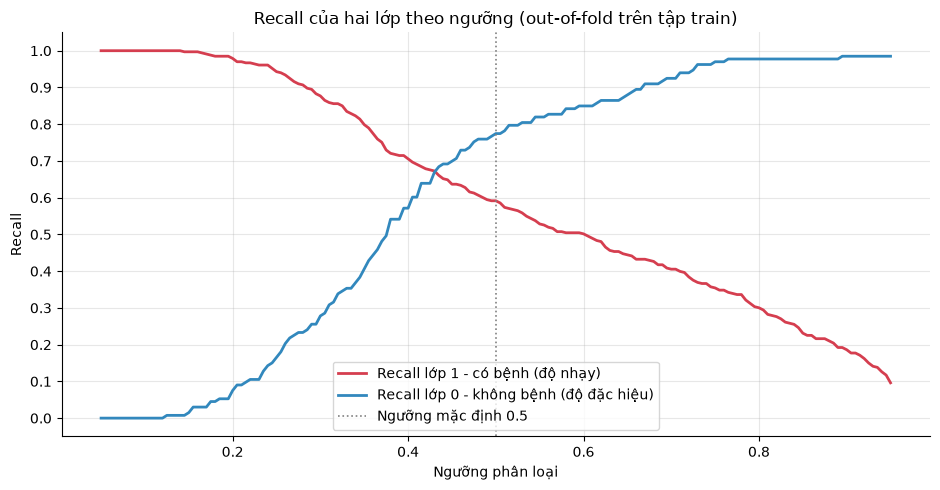

Bảng tra ngưỡng (tính trên out-of-fold của tập train):


,Ngưỡng,Recall lớp 1,Recall lớp 0
Recall mục tiêu (lớp 1),,,
0.70,0.402,0.703,0.586
0.75,0.372,0.751,0.489
0.80,0.350,0.802,0.406
0.85,0.324,0.853,0.338
0.90,0.283,0.901,0.241
0.95,0.246,0.952,0.150


Đọc bảng: đẩy recall lớp 1 lên thì recall lớp 0 tụt xuống - hai lớp đánh đổi trực tiếp.
Chọn mốc nào là quyết định về mặt lâm sàng, không phải bài toán tối ưu thuần tuý.


In [36]:
# ---- Recall / Precision thay đổi thế nào theo ngưỡng ----
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, precision_score, recall_score

best_model = gs.best_estimator_

# Dự đoán out-of-fold trên TẬP TRAIN: mỗi mẫu được chấm bởi mô hình chưa từng thấy nó.
# Toàn bộ việc phân tích và chọn ngưỡng làm trên đây, KHÔNG đụng tới tập test.
oof_proba = cross_val_predict(best_model, X_train, y_train,
                              cv=cv_inner, method='predict_proba')[:, 1]

# Quét ngưỡng từ 0.05 đến 0.95, tính recall cho CẢ HAI LỚP ở từng mức.
# Chỉ theo dõi recall: với bài toán bệnh tật, hai đại lượng cần cân nhắc là
#   recall lớp 1 = độ nhạy (sensitivity)  - bắt được bao nhiêu phần ca bệnh
#   recall lớp 0 = độ đặc hiệu (specificity) - loại đúng bao nhiêu phần người khoẻ
grid_thr = np.linspace(0.05, 0.95, 181)
curve = []
for t in grid_thr:
    pred_t = (oof_proba >= t).astype(int)
    curve.append({
        'Ngưỡng': t,
        'Recall lớp 1': recall_score(y_train, pred_t, pos_label=1, zero_division=0),
        'Recall lớp 0': recall_score(y_train, pred_t, pos_label=0, zero_division=0),
    })
curve_df = pd.DataFrame(curve).set_index('Ngưỡng')

plt.figure(figsize=(9.5, 5))
plt.plot(curve_df.index, curve_df['Recall lớp 1'], color='#d53e4f', lw=2,
         label='Recall lớp 1 - có bệnh (độ nhạy)')
plt.plot(curve_df.index, curve_df['Recall lớp 0'], color='#3288bd', lw=2,
         label='Recall lớp 0 - không bệnh (độ đặc hiệu)')
plt.axvline(0.5, color='gray', linestyle=':', lw=1.2, label='Ngưỡng mặc định 0.5')

plt.xlabel('Ngưỡng phân loại')
plt.ylabel('Recall')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.title('Recall của hai lớp theo ngưỡng (out-of-fold trên tập train)')
plt.legend()
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# Bảng tra: muốn đạt mức recall lớp 1 nào thì phải hạ ngưỡng tới đâu,
# và recall lớp 0 phải trả giá bao nhiêu
prec_c, rec_c, thr_c = precision_recall_curve(y_train, oof_proba)
lookup = []
for target in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    ok = rec_c[:-1] >= target
    if not ok.any():
        continue
    i = np.where(ok)[0][np.argmax(thr_c[np.where(ok)[0]])]   # ngưỡng cao nhất vẫn đạt target
    pred_t = (oof_proba >= thr_c[i]).astype(int)
    lookup.append({
        'Recall mục tiêu (lớp 1)': target,
        'Ngưỡng': thr_c[i],
        'Recall lớp 1': recall_score(y_train, pred_t, pos_label=1, zero_division=0),
        'Recall lớp 0': recall_score(y_train, pred_t, pos_label=0, zero_division=0),
    })
print("Bảng tra ngưỡng (tính trên out-of-fold của tập train):")
display(pd.DataFrame(lookup).set_index('Recall mục tiêu (lớp 1)').round(3))
print("Đọc bảng: đẩy recall lớp 1 lên thì recall lớp 0 tụt xuống - hai lớp đánh đổi trực tiếp.")
print("Chọn mốc nào là quyết định về mặt lâm sàng, không phải bài toán tối ưu thuần tuý.")

Ngưỡng mặc định của predict()        : 0.500
Ngưỡng chọn từ out-of-fold trên train: 0.402   (mục tiêu recall >= 0.7)

CONFUSION MATRIX (ngưỡng 0.402)
[[24 10]
 [14 69]]
  TN =  24   không bệnh, đoán đúng
  FP =  10   không bệnh nhưng báo có bệnh (báo động nhầm)
  FN =  14   CÓ BỆNH nhưng bỏ sót        <-- sai lầm tốn kém nhất
  TP =  69   có bệnh, bắt được

CLASSIFICATION REPORT
                precision    recall  f1-score   support

Không bệnh (0)      0.632     0.706     0.667        34
   Có bệnh (1)      0.873     0.831     0.852        83

      accuracy                          0.795       117
     macro avg      0.752     0.769     0.759       117
  weighted avg      0.803     0.795     0.798       117

Recall (có bệnh)    = TP/(TP+FN) = 69/(69+14) = 0.831
Precision (có bệnh) = TP/(TP+FP) = 69/(69+10) = 0.873

Đánh đổi khi hạ ngưỡng:


,FN (bỏ sót),FP (báo nhầm),Recall (có bệnh),Precision (có bệnh),Accuracy
Ngưỡng,,,,,
0.500 (mặc định),21,6,0.747,0.912,0.769
0.402 (đã chỉnh),14,10,0.831,0.873,0.795


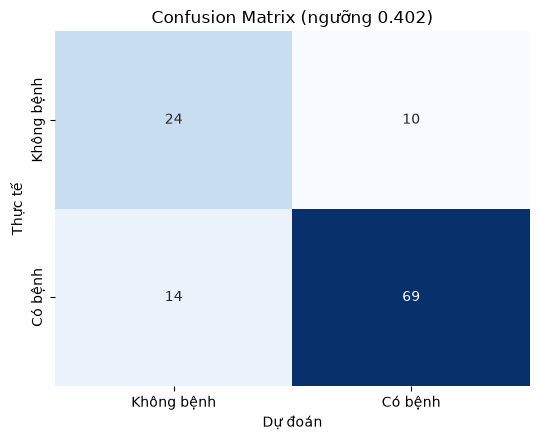

In [34]:
# ---- Chọn ngưỡng và đánh giá trên TẬP TEST ----
from sklearn.metrics import confusion_matrix, classification_report

# predict() của sklearn luôn dùng ngưỡng MẶC ĐỊNH 0.5, tối ưu cho độ chính xác tổng thể
# chứ không ưu tiên lớp nào. Trong bối cảnh y tế, bỏ sót ca bệnh (FN) tốn kém hơn nhiều
# so với báo động nhầm (FP), nên ta hạ ngưỡng xuống để đẩy recall lớp "có bệnh" lên.
#
# Mốc 0.7 chọn dựa trên biểu đồ và bảng tra ở cell trên.
TARGET_RECALL = 0.7      # mức recall tối thiểu muốn đạt cho lớp có bệnh - đổi mỗi số này

# Dùng lại oof_proba của cell trên: ngưỡng dò trên TẬP TRAIN, không đụng tập test.
# Nếu dò trên tập test rồi báo cáo luôn kết quả ở ngưỡng đó thì tập test đã tham gia
# vào một quyết định -> con số thu được lạc quan giả tạo.
prec, rec, thr = precision_recall_curve(y_train, oof_proba)
ok = rec[:-1] >= TARGET_RECALL                    # thr ngắn hơn rec/prec đúng 1 phần tử
threshold = thr[ok].max() if ok.any() else 0.5    # ngưỡng CAO NHẤT vẫn đạt mục tiêu
                                                  # -> precision tốt nhất có thể

# ===== Áp ngưỡng lên tập test (lần ĐẦU TIÊN tập test được đụng tới) =====
proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred = (proba_test >= threshold).astype(int)
y_pred_05 = (proba_test >= 0.5).astype(int)       # giữ lại để đối chiếu

print(f"Ngưỡng mặc định của predict()        : 0.500")
print(f"Ngưỡng chọn từ out-of-fold trên train: {threshold:.3f}"
      f"   (mục tiêu recall >= {TARGET_RECALL})\n")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()      # thứ tự của sklearn cho bài toán 2 lớp

print(f"CONFUSION MATRIX (ngưỡng {threshold:.3f})")
print(cm)
print(f"  TN = {tn:3d}   không bệnh, đoán đúng")
print(f"  FP = {fp:3d}   không bệnh nhưng báo có bệnh (báo động nhầm)")
print(f"  FN = {fn:3d}   CÓ BỆNH nhưng bỏ sót        <-- sai lầm tốn kém nhất")
print(f"  TP = {tp:3d}   có bệnh, bắt được")

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred,
                            target_names=['Không bệnh (0)', 'Có bệnh (1)'], digits=3))

print(f"Recall (có bệnh)    = TP/(TP+FN) = {tp}/({tp}+{fn}) = {tp/(tp+fn):.3f}")
print(f"Precision (có bệnh) = TP/(TP+FP) = {tp}/({tp}+{fp}) = {tp/(tp+fp):.3f}")

# Cái giá phải trả khi hạ ngưỡng: bắt thêm ca bệnh nhưng báo động nhầm nhiều hơn
cmp_rows = []
for name, pred in [('0.500 (mặc định)', y_pred_05), (f'{threshold:.3f} (đã chỉnh)', y_pred)]:
    a, b, c, d = confusion_matrix(y_test, pred).ravel()
    cmp_rows.append({
        'Ngưỡng': name,
        'FN (bỏ sót)': c, 'FP (báo nhầm)': b,
        'Recall (có bệnh)': d / (d + c),
        'Precision (có bệnh)': d / (d + b) if (d + b) else 0.0,
        'Accuracy': (a + d) / len(y_test),
    })
print("\nĐánh đổi khi hạ ngưỡng:")
display(pd.DataFrame(cmp_rows).set_index('Ngưỡng').round(3))

plt.figure(figsize=(5.5, 4.5))
labels = ['Không bệnh', 'Có bệnh']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title(f'Confusion Matrix (ngưỡng {threshold:.3f})')
plt.tight_layout()
plt.show()

## Giai đoạn 2. Bootstrap trên tập test

Mô hình đã chốt. Giờ mới mở niêm phong tập test, dự đoán một lần, rồi dùng bootstrap để trả lời: **con số vừa thu được chính xác đến mức nào?**

Cách làm: rút lại tập test có hoàn lại 2000 lần, mỗi lần tính lại các chỉ số, rồi lấy phân vị 2.5% và 97.5% làm khoảng tin cậy 95%. Mô hình giữ nguyên suốt quá trình — ta chỉ rút lại tập đánh giá.


In [ ]:
# ---- GIAI ĐOẠN 2: Bootstrap trên TẬP TEST ----
# Dùng lại best_model và y_pred đã tính ở cell trên - mô hình GIỮ NGUYÊN suốt quá trình,
# ta chỉ rút lại tập đánh giá.

# Các chỉ số điểm trên tập test
point = {
    'Recall (có bệnh)': recall_score(y_test, y_pred, pos_label=1),
    'Precision (có bệnh)': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Macro F1': f1_score(y_test, y_pred, average='macro'),
}

# Bootstrap: rút lại tập test có hoàn lại, cùng cỡ mẫu, lặp B lần.
# Mô hình GIỮ NGUYÊN suốt quá trình - ta chỉ rút lại tập đánh giá.
CONF = 0.95
B = 2000          # mức 95% -> đuôi 2.5% -> mỗi đuôi có ~50 giá trị, đủ ổn định
rng = np.random.default_rng(42)
n_test = len(y_test)

boot = []
for _ in range(B):
    idx = rng.integers(0, n_test, n_test)       # chỉ số rút có hoàn lại
    if y_test[idx].sum() == 0:                  # không có ca bệnh -> recall vô nghĩa
        continue
    boot.append({
        'Recall (có bệnh)': recall_score(y_test[idx], y_pred[idx], pos_label=1),
        'Precision (có bệnh)': precision_score(y_test[idx], y_pred[idx], pos_label=1,
                                               zero_division=0),
        'Accuracy': accuracy_score(y_test[idx], y_pred[idx]),
        'Macro F1': f1_score(y_test[idx], y_pred[idx], average='macro'),
    })

boot_df = pd.DataFrame(boot)

# Khoảng tin cậy percentile: cắt (1-CONF)/2 ở mỗi đuôi
tail = (1 - CONF) / 2 * 100
ci = pd.DataFrame({
    'Điểm ước lượng': pd.Series(point),
    f'CI {tail:g}%': boot_df.quantile(tail / 100),
    f'CI {100 - tail:g}%': boot_df.quantile(1 - tail / 100),
    'Sai số chuẩn': boot_df.std(ddof=1),
})

print(f"Bootstrap B = {len(boot_df)}, mức tin cậy {CONF:.0%}\n")
display(ci.round(4))

r = ci.loc['Recall (có bệnh)']
print(f"\nKết quả chính: Recall lớp có bệnh = {r['Điểm ước lượng']:.3f}, "
      f"KTC {CONF:.0%} [{r[f'CI {tail:g}%']:.3f}, {r[f'CI {100-tail:g}%']:.3f}]")

In [ ]:
# ---- Biểu đồ phân phối bootstrap ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Trái: phân phối Recall - chỉ số quan tâm chính
m = 'Recall (có bệnh)'
sns.histplot(boot_df[m], bins=40, kde=True, color='#66c2a5', ax=axes[0])
axes[0].axvline(point[m], color='crimson', linewidth=2,
                label=f'Điểm ước lượng = {point[m]:.3f}')
axes[0].axvline(ci.loc[m, f'CI {tail:g}%'], color='gray', linestyle='--', linewidth=1.5,
                label=f'KTC {CONF:.0%}')
axes[0].axvline(ci.loc[m, f'CI {100 - tail:g}%'], color='gray', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Recall lớp có bệnh')
axes[0].set_ylabel('Số lần xuất hiện')
axes[0].set_title(f'Phân phối bootstrap của Recall (B = {len(boot_df)})')
axes[0].legend(fontsize=9)

# Phải: khoảng tin cậy của cả 4 chỉ số
order = ci.index.tolist()
axes[1].errorbar(
    x=ci['Điểm ước lượng'], y=range(len(order)),
    xerr=[ci['Điểm ước lượng'] - ci[f'CI {tail:g}%'],
          ci[f'CI {100 - tail:g}%'] - ci['Điểm ước lượng']],
    fmt='o', color='#3288bd', ecolor='gray', capsize=5, markersize=8,
)
axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels(order)
axes[1].set_xlabel('Giá trị')
axes[1].set_title(f'Khoảng tin cậy {CONF:.0%} của các chỉ số')

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

In [ ]:
# ---- Đo độ lạc quan của best_score_ bằng NESTED CV ----
from sklearn.model_selection import cross_val_score

# Không thể đo độ lạc quan bằng cách lấy best_score_ trừ điểm trên tập test, vì hiệu số
# đó trộn lẫn HAI nguyên nhân: (a) lạc quan do chọn tham số, (b) tập test tình cờ dễ
# hay khó. Nested CV tách được (a) ra: vòng ngoài đánh giá TOÀN BỘ quy trình (bao gồm
# cả bước Grid Search bên trong), và cả hai con số đều tính trên cùng tập train.
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
nested = cross_val_score(gs, X_train, y_train, cv=cv_outer, scoring='f1_macro', n_jobs=-1)

test_f1 = f1_score(y_test, y_pred, average='macro')
comp = pd.DataFrame({
    'Macro F1': [gs.best_score_, nested.mean(), test_f1],
    'Tính trên': ['Train (5-Fold)', 'Train (nested CV)', 'Test (niêm phong)'],
    'Ý nghĩa': [
        'Điểm của bộ THẮNG CUỘC - đã dùng để chọn nên bị lạc quan',
        'Điểm trung thực của cả quy trình tune + fit',
        'Hiệu năng thực tế trên dữ liệu chưa từng thấy',
    ],
}, index=['best_score_', 'nested CV', 'tập test'])
display(comp.round(4))

sel_bias = gs.best_score_ - nested.mean()
split_luck = test_f1 - nested.mean()
scores_all = np.sort(gs.cv_results_['mean_test_score'])[::-1]
spread_top5 = scores_all[0] - scores_all[4]

print(f"best_score_ - nested CV = {sel_bias:+.4f}   <- độ lạc quan do CHỌN tham số")
print(f"tập test    - nested CV = {split_luck:+.4f}   <- ảnh hưởng của LẦN CHIA test")
print()
print("Đại lượng thứ nhất, theo lý thuyết, phải DƯƠNG: chọn bộ cao điểm nhất trong")
print(f"{len(scores_all)} bộ thì thế nào cũng dính chút may mắn. Ở đây nó gần như bằng 0 vì")
print(f"các bộ tham số cho điểm sát nhau - 5 bộ dẫn đầu chỉ chênh {spread_top5:.4f} - nên")
print("thực chất không có gì để 'chọn trúng may'. Logistic Regression trên bộ dữ liệu")
print("này gần như không nhạy với C, penalty hay k_neighbors. Với lưới tham số rộng")
print("hơn hoặc mô hình linh hoạt hơn (cây, boosting) thì độ lạc quan sẽ hiện rõ.")
print()
print("Đại lượng thứ hai lớn gấp nhiều lần và KHÔNG liên quan gì tới Grid Search:")
print("nó chỉ nói tập test của random_state=42 tình cờ dễ hơn mức trung bình.")
print("Đây chính là lý do không được lấy hiệu số (best_score_ - điểm test) để kết luận")
print("về độ lạc quan - hiệu số đó trộn lẫn cả hai nguyên nhân.")